In [ ]:
## download model weights from anonymous url: https://drive.google.com/drive/folders/1XWZXKQbb1geCd-_V4h2CffOtRqpugcSY?usp=drive_link
## put them to ./icd2fc/
## download the model weight from anonymous url: https://drive.google.com/drive/folders/1-zmOoMcAV6Qk35M4xV_gPK2Kqdb83EU2?usp=drive_link
## put it to icd10_tokenizer_posid/qwen-icd10-complete/best_model/model.safetensors

In [8]:
with open('example_icdseq.txt', 'r') as f:
    icdseq = f.read().split('\n')[:-1]
icdseq[:10]

['<|startoftext|> CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN E11-F00-G30-M17 CN CN CN CN CN CN CN CN CN CN CN CN CN CN <|endoftext|>',
 '<|startoftext|> CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN E78-E78-I10-I20-I25-J44-N40-Z86-Z88-Z92 CN CN CN CN CN B98-D50-K22-K29-K44 CN CN CN CN CN CN CN CN <|endoftext|>',
 '<|startoftext|> CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN B96-K29-R10-Z90 CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN K21 CN CN CN I10-R10-R13-R63 K52-K57-K59-Z80 C18-E03-E73-E87-K44-K58-N39-N73-R18-U82-Z50-Z50-Z87-Z88-Z90-Z91 C78-J18-J39-K25-K56-R00-R11-R14-R40-R69-Z11-Z51-Z85-Z88-Z88-Z88-Z90-Z93 CN CN CN CN CN <|endoftext|>',
 '<|startoftext|> CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN CN C

In [9]:
import torch
from event_complete_tokenizer import tokenizer, tokenizer_encode, tokenizer_decode, vocab_size

max_len = 300
seqlist = []
for line in icdseq:
    input_ids, seq_posids = tokenizer_encode(line)
    
    # Create tensors
    input_ids = torch.LongTensor(input_ids)
    seq_posids = torch.LongTensor(seq_posids)
    attn_mask = torch.ones_like(input_ids)
    
    # Padding logic
    pad_len = max_len - len(input_ids)
    if pad_len > 0:
        input_ids = torch.cat([input_ids, torch.zeros(pad_len, dtype=torch.long)])
        seq_posids = torch.cat([seq_posids, torch.zeros(pad_len, dtype=torch.long)])
        attn_mask = torch.cat([attn_mask, torch.zeros(pad_len, dtype=torch.long)])
    else:
        # Safety truncation if line is longer than max_len
        input_ids = input_ids[:self.max_len]
        seq_posids = seq_posids[:self.max_len]
        attn_mask = attn_mask[:self.max_len]

    seqlist.append({
        "input_ids": input_ids,
        "seq_posids": seq_posids,
        "attention_mask": attn_mask,
    })

In [10]:

from transformers import Qwen3ForCausalLM, get_scheduler
device = 'cuda:1'
model = Qwen3ForCausalLM.from_pretrained('icd10_tokenizer_posid/qwen-icd10-complete/best_model').to(device)
model.config.max_position_embeddings

300

In [11]:
batch = {k: torch.stack([seq[k] for seq in seqlist]) for k in seqlist[0]}
seq_posids = batch["seq_posids"].to(device)
input_ids = batch["input_ids"].to(device)
mask = batch["attention_mask"].to(device)
labels = input_ids[:, 2:]
input_ids.shape

torch.Size([100, 300])

In [12]:
input_ids.max()

tensor(1943, device='cuda:1')

In [13]:
model

Qwen3ForCausalLM(
  (model): Qwen3Model(
    (embed_tokens): Embedding(1945, 512)
    (layers): ModuleList(
      (0-11): 12 x Qwen3DecoderLayer(
        (self_attn): Qwen3Attention(
          (q_proj): Linear(in_features=512, out_features=1024, bias=False)
          (k_proj): Linear(in_features=512, out_features=1024, bias=False)
          (v_proj): Linear(in_features=512, out_features=1024, bias=False)
          (o_proj): Linear(in_features=1024, out_features=512, bias=False)
          (q_norm): Qwen3RMSNorm((128,), eps=1e-06)
          (k_norm): Qwen3RMSNorm((128,), eps=1e-06)
        )
        (mlp): Qwen3MLP(
          (gate_proj): Linear(in_features=512, out_features=5504, bias=False)
          (up_proj): Linear(in_features=512, out_features=5504, bias=False)
          (down_proj): Linear(in_features=5504, out_features=512, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): Qwen3RMSNorm((512,), eps=1e-06)
        (post_attention_layernorm): Qwen

In [23]:
model.eval()
with torch.no_grad():
    outputs = model(
        input_ids=input_ids, 
        attention_mask=mask, 
        position_ids=seq_posids, output_hidden_states=True
    )
logits = outputs["logits"][:, 1:-1] # (100, seq_len, vocab)

In [24]:
logits.shape, labels.shape

(torch.Size([100, 298, 1945]), torch.Size([100, 298]))

<Axes: >

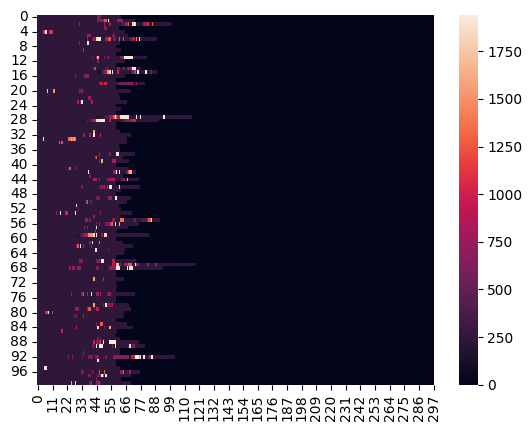

In [25]:
import seaborn as sns
sns.heatmap(logits.argmax(-1).detach().cpu().numpy())

<Axes: >

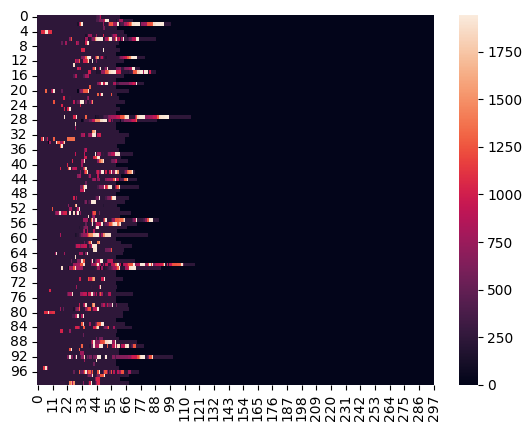

In [26]:
sns.heatmap(labels.detach().cpu().numpy())

In [27]:
outputs.keys()

odict_keys(['logits', 'hidden_states'])

In [31]:
text_cond = outputs['hidden_states'][-1]
text_cond.shape

torch.Size([100, 300, 512])

In [32]:
import torchvision
import yaml
import os
from torchvision.utils import make_grid
from tqdm import tqdm
from scheduler.linear_noise_scheduler import LinearNoiseScheduler
from utils.config_utils import *
from models.vqvae import SPD_VQVAE
from models.cholesky_ddpm import LatentMLPDiffusion
import torch

config_path = 'config/icd2fc_image_cond.yaml'
# Read the config file #
with open(config_path, 'r') as file:
    try:
        config = yaml.safe_load(file)
    except yaml.YAMLError as exc:
        print(exc)
print(config)
########################

diffusion_config = config['diffusion_params']
dataset_config = config['dataset_params']
# dataset_config['im_size'] = 120
diffusion_model_config = config['ldm_params']
autoencoder_model_config = config['autoencoder_params']
train_config = config['train_params']
diffusion_config['num_timesteps'] = 100

########## Create the noise scheduler #############
scheduler = LinearNoiseScheduler(num_timesteps=diffusion_config['num_timesteps'],
                                 beta_start=diffusion_config['beta_start'],
                                 beta_end=diffusion_config['beta_end'])
###############################################

ldm = LatentMLPDiffusion(model_config=diffusion_model_config, input_shape=[256+16,256]).to(device)
ldm.eval()
ldm.load_state_dict(torch.load('icd2fc/best_DualSPD_thr25vqvae_ddpm_ckpt_text_image_cond_clip.pth'))
autoencoder_config = config['autoencoder_params']

model1 = SPD_VQVAE(input_dim=116,
                      model_config=autoencoder_config,
                   num_latents=256,).to(device)
model1.load_state_dict(torch.load('icd2fc/DualSPD_thr25_m1vqvae_autoencoder_ckpt.pth',
                                 map_location=device))

model2 = SPD_VQVAE(input_dim=116,
                  model_config=autoencoder_config,
                   num_latents=16, # 
                   codebook_size=16 # 
                  ).to(device)
model2.load_state_dict(torch.load('icd2fc/DualSPD_thr25_m2vqvae_autoencoder_ckpt.pth',
                                 map_location=device))
model1.eval()
model2.eval()


{'dataset_params': {'im_path': 'placeholder', 'im_channels': 1, 'im_size': 116, 'name': 'ICDFC'}, 'diffusion_params': {'num_timesteps': 1000, 'beta_start': 0.00085, 'beta_end': 0.012}, 'ldm_params': {'down_channels': [128, 256, 384, 512], 'mid_channels': [512, 384], 'down_sample': [True, True, True], 'attn_down': [True, True, True], 'time_emb_dim': 512, 'norm_channels': 32, 'num_heads': 8, 'conv_out_channels': 128, 'num_down_layers': 1, 'num_mid_layers': 2, 'num_up_layers': 1, 'condition_config': {'condition_types': ['text'], 'text_condition_config': {'text_embed_model': 'clip', 'train_text_embed_model': False, 'text_embed_dim': 512, 'cond_drop_prob': 0.1}, 'image_condition_config': {'image_condition_input_channels': 1, 'image_condition_output_channels': 1, 'image_condition_h': 120, 'image_condition_w': 120, 'cond_drop_prob': 0.1}}}, 'autoencoder_params': {'z_channels': 1, 'codebook_size': 8192, 'down_channels': [64, 128, 256, 256], 'mid_channels': [256, 256], 'down_sample': [True, Tru

SPD_VQVAE(
  (encoder_body): Sequential(
    (0): Linear(in_features=13456, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): SiLU()
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): SiLU()
    (6): Linear(in_features=256, out_features=128, bias=True)
    (7): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): SiLU()
  )
  (encoder_out): Linear(in_features=128, out_features=4096, bias=True)
  (embedding): Embedding(16, 256)
  (decoder_body): Sequential(
    (0): Linear(in_features=4096, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): SiLU()
    (3): Linear(in_features=128, out_features=256, bias=True)
    (4): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats

In [33]:

def reverse_decomp(comp1, comp2):
    n = comp1.shape[-1]
    batch_mat = torch.zeros(len(comp1), n, n)
    tril_idx = torch.tril_indices(n, n)
    triu_idx = torch.triu_indices(n, n)
    batch_mat[:, tril_idx[0], tril_idx[1]] = torch.fft.irfft(torch.fft.rfft(comp1[:, tril_idx[0], tril_idx[1]], dim=-1) + torch.fft.rfft(comp2[:, tril_idx[0], tril_idx[1]], dim=-1), n=tril_idx.shape[-1], dim=-1).detach().cpu()
    batch_mat[:, triu_idx[0], triu_idx[1]] = batch_mat[:, triu_idx[1], triu_idx[0]]
    return batch_mat
    

In [34]:
diffusion_config['num_timesteps']

100

In [40]:

xt = torch.randn((text_cond.shape[0],
                  256+16,
                  256)).to(device)
###############################################
cond_input = {}
cond_input['text'] = text_cond.to(device)

################# Sampling Loop ########################
all_ims = []
with torch.no_grad():
    for i in tqdm(reversed(range(diffusion_config['num_timesteps'])), desc=f'denoising'):
        # Get prediction of noise
        t = (torch.ones((xt.shape[0],)) * i).long().to(device)
        noise_pred_cond = ldm(xt, t, cond_input=cond_input)
        
        # if cf_guidance_scale > 1:
        #     noise_pred_uncond = model(xt, t, uncond_input)
        #     noise_pred = noise_pred_uncond + cf_guidance_scale * (noise_pred_cond - noise_pred_uncond)
        # else:
        noise_pred = noise_pred_cond
        
        # Use scheduler to get x0 and xt-1
        xt, x0_pred = scheduler.sample_prev_timestep(xt, noise_pred, torch.as_tensor(i).to(device), spd=False)
        
        # Save x0
        if i == 0:
            # Decode ONLY the final image to save time
            ims = xt
        else:
            ims = x0_pred
        
        # ims = torch.clamp(ims, -1., 1.).detach().cpu()
        # ims = (ims + 1) / 2
        all_ims.append(ims)

pred_z = all_ims[-1]

denoising: 100it [01:14,  1.34it/s]


torch.Size([100, 116, 116])

torch.Size([100, 272, 256])

In [75]:
with torch.no_grad():
    all_decoded_output1 = model1.decode(model1.quantize(pred_z[:, :256].contiguous())[0])[0].detach().cpu().squeeze()
    all_decoded_output2 = model2.decode(model2.quantize(pred_z[:, 256:].contiguous())[0])[0].detach().cpu().squeeze()

all_decoded_output = reverse_decomp(all_decoded_output1.squeeze(), all_decoded_output2.squeeze()).tanh()
all_decoded_output[:, torch.arange(all_decoded_output.shape[-1]), torch.arange(all_decoded_output.shape[-1])] = 1
all_decoded_output.shape

torch.Size([100, 116, 116])

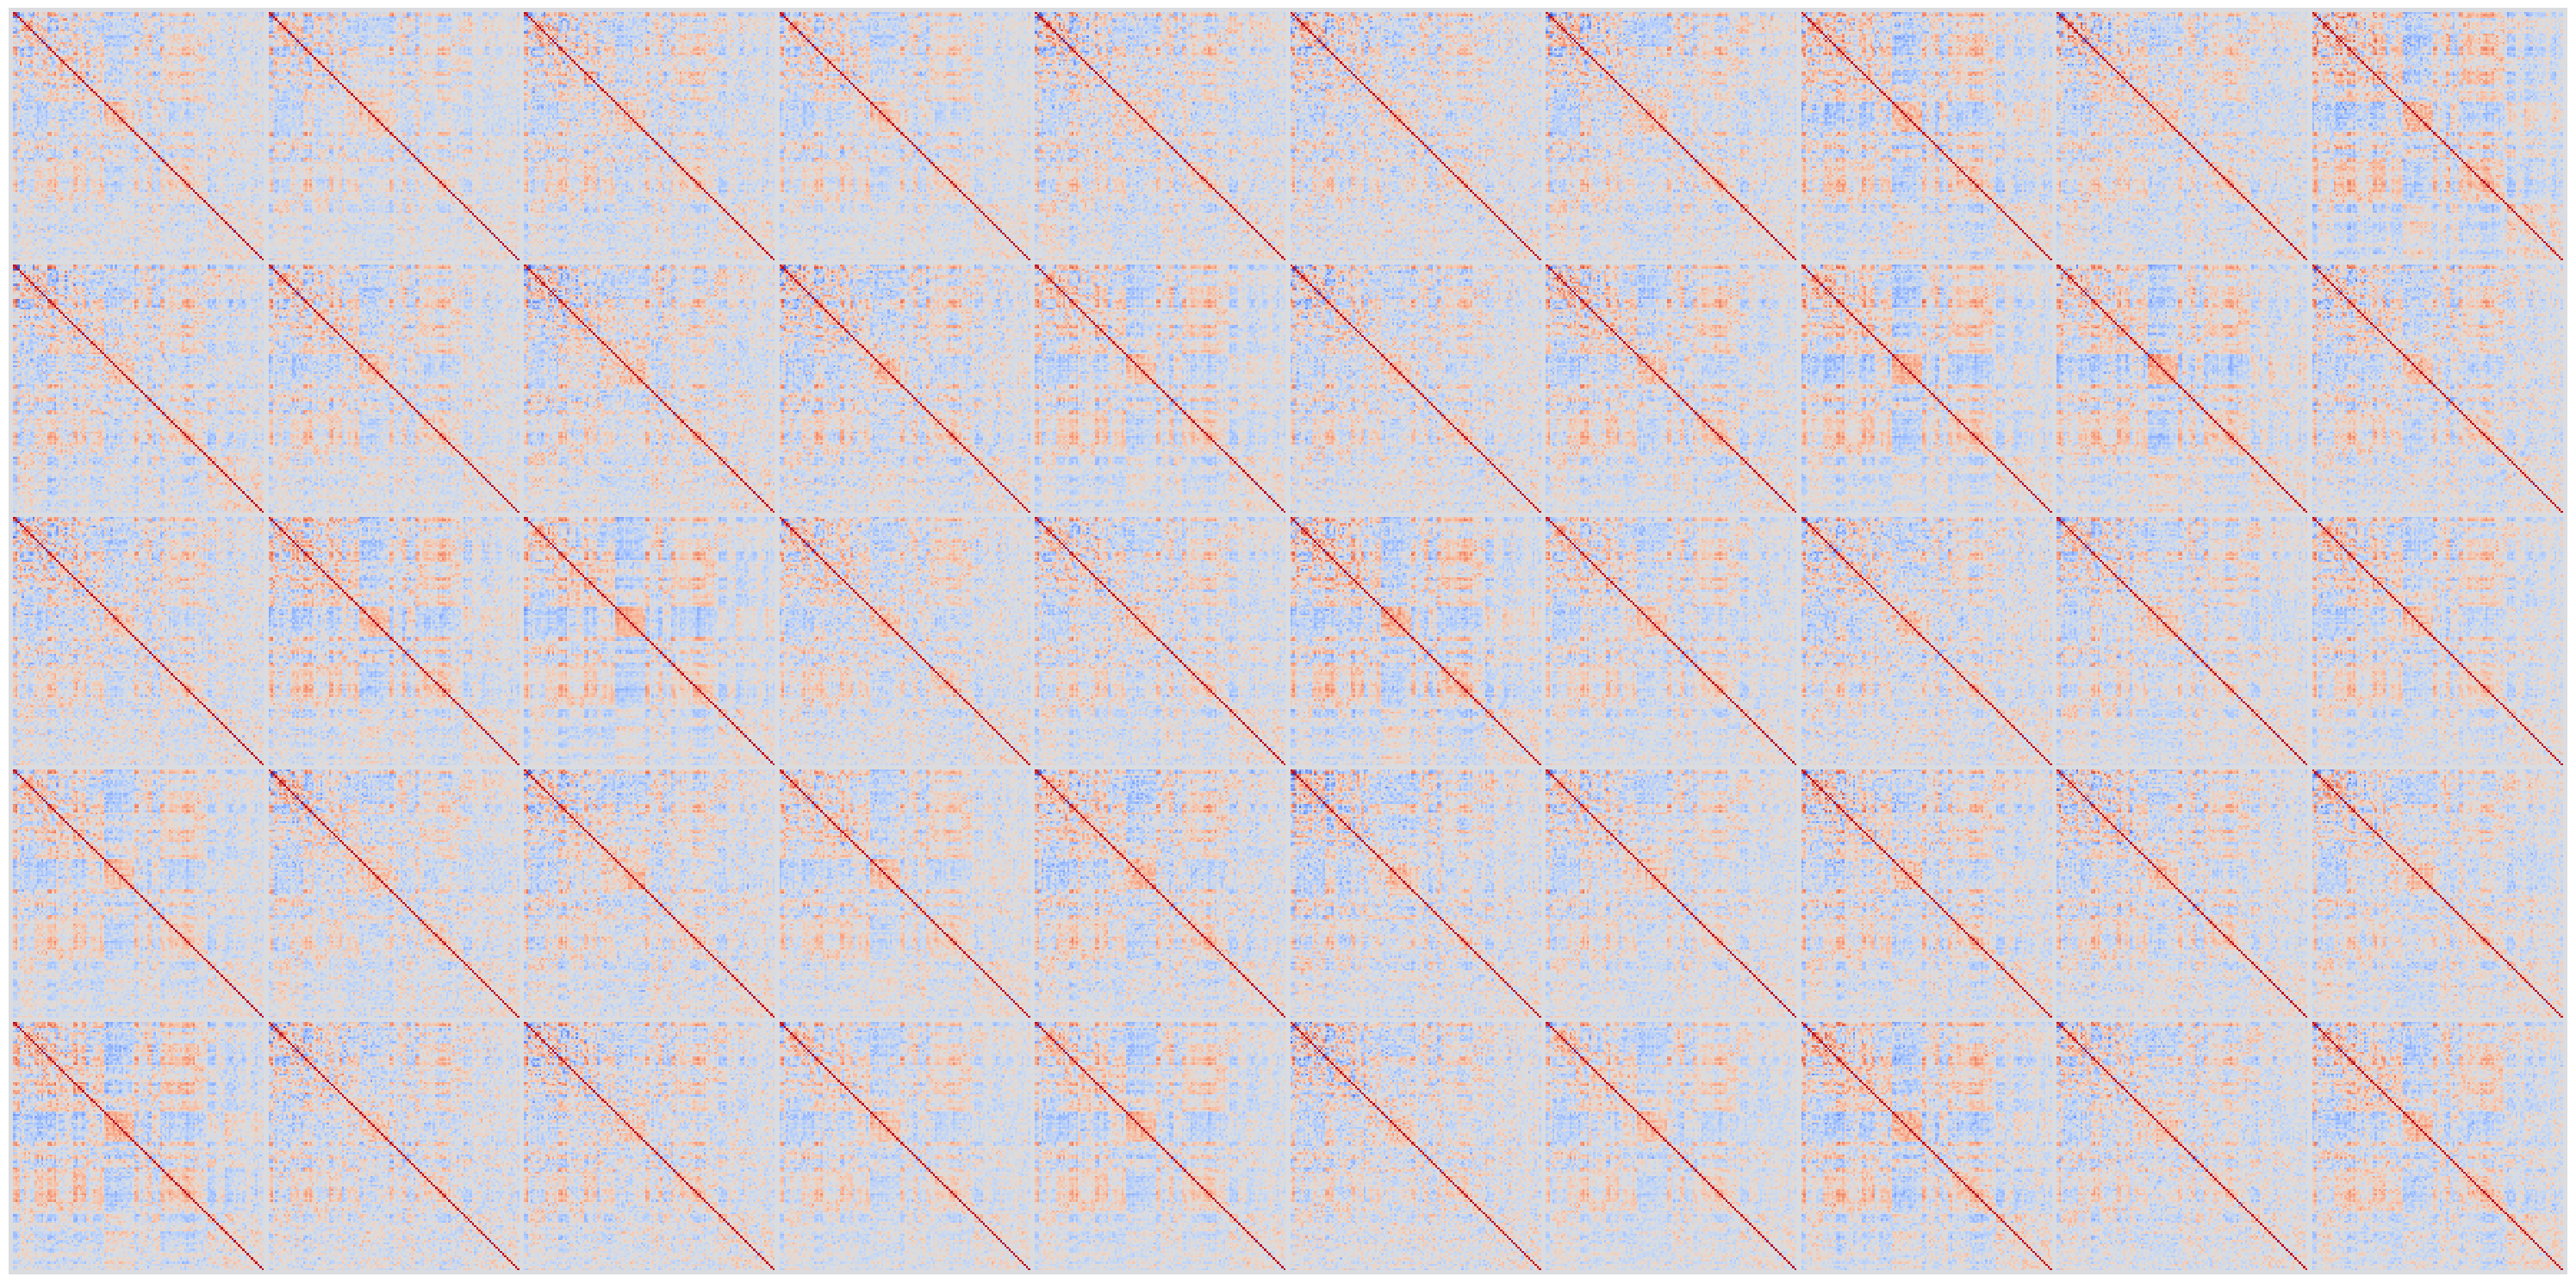

In [76]:
import matplotlib.pyplot as plt
grid = make_grid(all_decoded_output[:50, None], nrow=10)
plt.figure(figsize=(30,15))
sns.heatmap(grid[0], cmap='coolwarm', cbar=False)
plt.xticks([])
plt.yticks([])
plt.tight_layout()